# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [42]:
# Import standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pubchempy as pcp
import tarfile
import re

from sklearn.preprocessing import StandardScaler
from statsmodels.api import add_constant, OLS, Logit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn.metrics import balanced_accuracy_score
from sklearn.neural_network import MLPClassifier

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs import ConvertToNumpyArray
import umap.umap_ as umap


In [3]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
print("Shape of the master file:", master_file.shape)
master_file.head()

Shape of the master file: (48152, 114)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_19138/3102753570.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [4]:
# Drop some initial columns that we won't be using, many which are text results and would be difficult to use for models

remove_columns = ["effect", "genomic position", "algorithm_pass", "Initial confidence grading",
                                              "DATASET(S)", "INITIAL CONFIDENCE GRADING", "Initial confidence grading WHO dataset", "Comment",
                                              "CHANGES vs ver1","Relaxed thresholds simulation",
                                              "Listed in abridged tables","Additional grading", "Footnote", "CHANGES vs ver1", 
                                              "(WHO guidance before cat ver1)", "Previous WHO guidance"
                                                ]

pattern = '|'.join(map(re.escape, remove_columns))
master_file_clean = master_file.copy()
master_file_clean = master_file_clean.loc[:, ~master_file_clean.columns.str.contains(pattern, case=False)]


In [5]:
# check distribution of WHO grades
print(master_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(master_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


In [6]:
master_file_clean["gene"] = master_file_clean["gene"].str.strip()
master_file_clean["mutation"] = master_file_clean["mutation"].str.strip()
master_file_clean["FINAL CONFIDENCE GRADING"] = master_file_clean["FINAL CONFIDENCE GRADING"].str.strip()

print(master_file_clean["FINAL CONFIDENCE GRADING"].unique())

# ordinally encode resistance grades
grading_scheme = {
    "5) Not assoc w R": 0,
    "4) Not assoc w R - Interim'": 1,
    "3) Uncertain significance": 2,
    "2) Assoc w R - Interim": 3,
    "1) Assoc w R": 4
}

master_file_clean["grade_ordinal"] = master_file_clean["FINAL CONFIDENCE GRADING"].map(grading_scheme)
master_file_clean = master_file_clean.dropna(subset=["grade_ordinal"])

# remove duplicates
master_file_clean = master_file_clean.drop_duplicates(subset=["mutation", "drug"])
#print(master_file_clean.head())
print(master_file_clean.columns)


['4) Not assoc w R - Interim' '5) Not assoc w R'
 '3) Uncertain significance' '2) Assoc w R - Interim' '1) Assoc w R']
Index(['drug', 'gene', 'mutation', 'variant', 'tier',
       'Present_SOLO_SR_DATASET ALL', 'Present_SOLO_R_DATASET ALL',
       'Present_SOLO_S_DATASET ALL', 'Present_R_DATASET ALL',
       'Present_S_DATASET ALL', 'Absent_R_DATASET ALL', 'Absent_S_DATASET ALL',
       'Sens_DATASET ALL', 'Sens_lb_DATASET ALL', 'Sens_ub_DATASET ALL',
       'Spec_DATASET ALL', 'Spec_lb_DATASET ALL', 'Spec_ub_DATASET ALL',
       'PPV_DATASET ALL', 'PPV_lb_DATASET ALL', 'PPV_ub_DATASET ALL',
       'PPV_SOLO_DATASET ALL', 'PPV_SOLO_lb_DATASET ALL',
       'PPV_SOLO_ub_DATASET ALL', 'PPV_conditional_SOLO_DATASET ALL',
       'PPV_conditional_SOLO_lb_DATASET ALL',
       'PPV_conditional_SOLO_ub_DATASET ALL', 'OR_SOLO_DATASET ALL',
       'OR_SOLO_exact_lb_DATASET ALL', 'OR_SOLO_exact_ub_DATASET ALL',
       'OR_SOLO_pvalue_DATASET ALL', 'OR_SOLO_pval_rank_DATASET ALL',
       'k_DATASET

In [7]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# get the smiles for the drugs
def get_smiles(drug_name):
    try:
        compounds = pcp.get_compounds(drug_name, "name")
        if len(compounds) > 0:
            return compounds[0].connectivity_smiles
    except:
        return None
    return None

#apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].apply(get_smiles)

# add fingerprints to dataset
morgan_generator = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((2048, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)

# merge drugs to the model df
final_data = master_file_clean.merge(TB_drugs, on="drug", how="left")
final_data.head()

,drug,gene,mutation,variant,tier,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,Present_SOLO_S_DATASET ALL,Present_R_DATASET ALL,Present_S_DATASET ALL,...,Sens_SOLO_ub_DATASET WHO,Spec_SOLO_DATASET WHO,Spec_SOLO_lb_DATASET WHO,Spec_SOLO_ub_DATASET WHO,Present_NoPheno_no pDST,FINAL CONFIDENCE GRADING,Silent mutation,grade_ordinal,smiles,fingerprint
0,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,NaN,NaN,NaN,91.0,1112.0,...,NaN,NaN,NaN,NaN,1049.0,5) Not assoc w R,Silent mutation,0.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Amikacin,bacA,c.-18T>C,bacA_c.-18T>C,2,1.0,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,1.0,3) Uncertain significance,NaN,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Amikacin,bacA,c.-21G>A,bacA_c.-21G>A,2,1.0,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,1.0,3) Uncertain significance,NaN,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Amikacin,bacA,c.-32G>A,bacA_c.-32G>A,2,0.0,0.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,3) Uncertain significance,NaN,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Amikacin,bacA,c.-32G>T,bacA_c.-32G>T,2,1.0,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,3) Uncertain significance,NaN,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [8]:
# change Nan for columns startign with Present, Sense, and Spec to -1 since they were not observed in the data, and we want to keep them for the model
for col in final_data.columns:
    if col.startswith(("Present", "Sens", "Spec")):
        final_data[col] = final_data[col].fillna(-1)

final_data["Silent mutation"] = (final_data["Silent mutation"] == "Silent mutation").astype(int)
final_data = final_data.drop(columns=["FINAL CONFIDENCE GRADING", "variant"])
final_data.head()

,drug,gene,mutation,tier,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,Present_SOLO_S_DATASET ALL,Present_R_DATASET ALL,Present_S_DATASET ALL,Absent_R_DATASET ALL,...,Sens_SOLO_lb_DATASET WHO,Sens_SOLO_ub_DATASET WHO,Spec_SOLO_DATASET WHO,Spec_SOLO_lb_DATASET WHO,Spec_SOLO_ub_DATASET WHO,Present_NoPheno_no pDST,Silent mutation,grade_ordinal,smiles,fingerprint
0,Amikacin,bacA,c.1044G>A,2,-1.0,-1.0,-1.0,91.0,1112.0,2369.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,1049.0,1,0.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Amikacin,bacA,c.-18T>C,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,0,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Amikacin,bacA,c.-21G>A,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,0,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Amikacin,bacA,c.-32G>A,2,0.0,0.0,0.0,1.0,0.0,2459.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Amikacin,bacA,c.-32G>T,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0,2.0,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [9]:
# Splitting the mutation column up to make fewer columns when one hot encoding
import re
# Amino acid 3-letter to 1-letter code map
AA_MAP = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Gln': 'Q', 'Glu': 'E', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V',
    'Ter': '*', 'Stop': '*'
}

def parse_aa(code):
    """Convert 3-letter amino acid code to 1-letter, or return as-is if already 1-letter or stop."""
    if code == '*':
        return '*'
    return AA_MAP.get(code, code)


def extract_features(mutation):

    PREFIX = r'[cn]\.'

    # -------------------------
    # PROTEIN-LEVEL: p. notation
    # -------------------------

    # Stop extension: p.Ter559Glnext*? or p.Ter559ext*? or p.Ter628Serext*?
    p_ext = re.match(r'p\.Ter(\d+)([A-Z][a-z]{2})?ext\*\?$', mutation)
    if p_ext:
        pos, alt_aa = p_ext.groups()
        return {'mut_type': 'extension', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': '*', 'alt': parse_aa(alt_aa) if alt_aa else None}

    # Stop codon unknown delins: p.Ter839delins???
    p_ter_delins = re.match(r'p\.Ter(\d+)delins\?+$', mutation)
    if p_ter_delins:
        pos = p_ter_delins.group(1)
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': '*', 'alt': None}

    # Frameshift: p.Asp379fs
    p_fs = re.match(r'p\.([A-Z][a-z]{2})(\d+)fs$', mutation)
    if p_fs:
        ref_aa, pos = p_fs.groups()
        return {'mut_type': 'frameshift', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Stop/nonsense: p.Trp122*
    p_stop = re.match(r'p\.([A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_stop:
        ref_aa, pos = p_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': '*'}

    # Malformed nonsense: p.TrpLeu266*
    p_malformed_stop = re.match(r'p\.([A-Z][a-z]{2}[A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_malformed_stop:
        ref_aa, pos = p_malformed_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': None, 'alt': '*'}

    # Uncertain: p.Met1?
    p_uncertain = re.match(r'p\.([A-Z][a-z]{2})(\d+)\?$', mutation)
    if p_uncertain:
        ref_aa, pos = p_uncertain.groups()
        return {'mut_type': 'uncertain', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Single AA deletion: p.Leu95del
    p_single_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_single_del:
        ref_aa, pos = p_single_del.groups()
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA deletion: p.Val3_Thr4del
    p_range_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_range_del:
        ref_aa, start, _, end = p_range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA duplication: p.His68_Leu70dup
    p_range_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_range_dup:
        ref_aa, start, _, end = p_range_dup.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA insertion: p.Val389_Asp390insGly  (one or more 3-letter AA codes)
    p_range_ins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)ins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_ins:
        ref_aa, start, _, end, ins_aas = p_range_ins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA delins: p.Pro14_Val301delinsLeu or p.Leu443_Lys446delinsProGln
    p_range_delins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)delins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_delins:
        ref_aa, start, _, end, ins_aas = p_range_delins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Missense: p.Ala152Val  (must come after all range patterns)
    p_missense = re.match(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})$', mutation)
    if p_missense:
        ref_aa, pos, alt_aa = p_missense.groups()
        return {'mut_type': 'missense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': parse_aa(alt_aa)}

    # Duplication single AA: p.Ala285dup
    p_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_dup:
        ref_aa, pos = p_dup.groups()
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1,
                'ref': parse_aa(ref_aa), 'alt': None}

    # -------------------------
    # DNA/RNA-LEVEL: c. or n. notation
    # -------------------------

    snv = re.match(PREFIX + r'(-?\d+)([ACGT])>([ACGT])$', mutation)
    if snv:
        pos, ref, alt = snv.groups()
        return {'mut_type': 'SNV', 'position': int(pos), 'del_len': 0, 'ins_len': 0, 'ref': ref, 'alt': alt}

    single_del = re.match(PREFIX + r'(-?\d+)del[ACGT]*$', mutation)
    if single_del:
        pos = single_del.group(1)
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0, 'ref': None, 'alt': None}

    range_del = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*$', mutation)
    if range_del:
        start, end = range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    ins = re.match(PREFIX + r'(-?\d+)_(-?\d+)ins([ACGT]+)$', mutation)
    if ins:
        start, end, bases = ins.groups()
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0, 'ins_len': len(bases), 'ref': None, 'alt': None}

    delins = re.match(PREFIX + r'(-?\d+)del[ACGT]*ins([ACGT]+)$', mutation)
    if delins:
        pos, ins_bases = delins.groups()
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': len(ins_bases), 'ref': None, 'alt': None}

    range_delins = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*ins[ACGT]+$', mutation)
    if range_delins:
        start, end = range_delins.groups()
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    dup_single = re.match(PREFIX + r'(-?\d+)dup[ACGT]*$', mutation)
    if dup_single:
        pos = dup_single.group(1)
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1, 'ref': None, 'alt': None}

    dup_range = re.match(PREFIX + r'(-?\d+)_(-?\d+)dup[ACGT]*$', mutation)
    if dup_range:
        start, end = dup_range.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': None, 'alt': None}

    # -------------------------
    # FREE TEXT
    # -------------------------
    mutation_lower = mutation.lower()
    if 'lof' in mutation_lower or 'loss of function' in mutation_lower:
        return {'mut_type': 'LoF', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}
    if 'deletion' in mutation_lower:
        return {'mut_type': 'del', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}

    return {'mut_type': 'unknown', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}

one_hot_df = final_data.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# --- Check how many fell through to unknown ---
print(one_hot_df['mut_type'].value_counts())
unknown_mask = one_hot_df['mut_type'] == 'unknown'
print(f"\n{unknown_mask.sum()} unparsed mutations:")
for m in one_hot_df.loc[unknown_mask, 'mutation'].unique()[:200]:
    print(m)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['mut_type', 'ref', 'alt'], dummy_na=True)


print(f"num features: {len(one_hot_df.columns)}")
print(one_hot_df.columns)
one_hot_df.head()

mut_type
missense      22568
SNV            8223
frameshift     2074
del             598
nonsense        582
ins             263
delins          229
dup             225
extension        47
LoF              15
uncertain        14
Name: count, dtype: int64

0 unparsed mutations:
num features: 153
Index(['drug', 'gene', 'mutation', 'tier', 'Present_SOLO_SR_DATASET ALL',
       'Present_SOLO_R_DATASET ALL', 'Present_SOLO_S_DATASET ALL',
       'Present_R_DATASET ALL', 'Present_S_DATASET ALL',
       'Absent_R_DATASET ALL',
       ...
       'alt_N', 'alt_P', 'alt_Q', 'alt_R', 'alt_S', 'alt_T', 'alt_V', 'alt_W',
       'alt_Y', 'alt_nan'],
      dtype='object', length=153)


,drug,gene,mutation,tier,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,Present_SOLO_S_DATASET ALL,Present_R_DATASET ALL,Present_S_DATASET ALL,Absent_R_DATASET ALL,...,alt_N,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,alt_nan
0,Amikacin,bacA,c.1044G>A,2,-1.0,-1.0,-1.0,91.0,1112.0,2369.0,...,False,False,False,False,False,False,False,False,False,False
1,Amikacin,bacA,c.-18T>C,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,False,False,False,False,False,False,False,False,False,False
2,Amikacin,bacA,c.-21G>A,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,False,False,False,False,False,False,False,False,False,False
3,Amikacin,bacA,c.-32G>A,2,0.0,0.0,0.0,1.0,0.0,2459.0,...,False,False,False,False,False,False,False,False,False,False
4,Amikacin,bacA,c.-32G>T,2,1.0,0.0,1.0,0.0,1.0,2460.0,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
one_hot_copy = one_hot_df.copy()
one_hot_copy = one_hot_copy.drop(columns=["mutation"])
one_hot_copy["gene"] = one_hot_copy["gene"].astype("category").cat.codes

#keep track of mapping for later
lookup_drugs = dict(enumerate(one_hot_df["drug"].astype("category").cat.categories))
print(lookup_drugs) # this is the mapping of drug names to codes, we will need this to identify the codes for the drugs we want to hold out

one_hot_copy["drug"] = one_hot_copy["drug"].astype("category").cat.codes
one_hot_copy.head()

{0: 'Amikacin', 1: 'Bedaquiline', 2: 'Capreomycin', 3: 'Clofazimine', 4: 'Delamanid', 5: 'Ethambutol', 6: 'Ethionamide', 7: 'Isoniazid', 8: 'Kanamycin', 9: 'Levofloxacin', 10: 'Linezolid', 11: 'Moxifloxacin', 12: 'Pyrazinamide', 13: 'Rifampicin', 14: 'Streptomycin'}


,drug,gene,tier,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,Present_SOLO_S_DATASET ALL,Present_R_DATASET ALL,Present_S_DATASET ALL,Absent_R_DATASET ALL,Absent_S_DATASET ALL,...,alt_N,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,alt_nan
0,0,17,2,-1.0,-1.0,-1.0,91.0,1112.0,2369.0,20866.0,...,False,False,False,False,False,False,False,False,False,False
1,0,17,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,...,False,False,False,False,False,False,False,False,False,False
2,0,17,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,...,False,False,False,False,False,False,False,False,False,False
3,0,17,2,0.0,0.0,0.0,1.0,0.0,2459.0,21978.0,...,False,False,False,False,False,False,False,False,False,False
4,0,17,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,...,False,False,False,False,False,True,False,False,False,False


In [26]:
# Now we need to convert the fingerprint arrays into separate columns for each bit, so we can use them in the model
encoded_df = pd.DataFrame(one_hot_copy["fingerprint"].tolist(), index=one_hot_copy.index)
encoded_df.columns = [f"fp_{i}" for i in range(encoded_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([one_hot_copy.drop(columns=["fingerprint", "smiles"]), encoded_df], axis=1)
print(final_ml.shape)
final_ml.head()

(34838, 2198)


,drug,gene,tier,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,Present_SOLO_S_DATASET ALL,Present_R_DATASET ALL,Present_S_DATASET ALL,Absent_R_DATASET ALL,Absent_S_DATASET ALL,...,fp_2038,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047
0,0,17,2,-1.0,-1.0,-1.0,91.0,1112.0,2369.0,20866.0,...,0,0,0,0,0,0,0,0,0,0
1,0,17,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,...,0,0,0,0,0,0,0,0,0,0
2,0,17,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,...,0,0,0,0,0,0,0,0,0,0
3,0,17,2,0.0,0.0,0.0,1.0,0.0,2459.0,21978.0,...,0,0,0,0,0,0,0,0,0,0
4,0,17,2,1.0,0.0,1.0,0.0,1.0,2460.0,21977.0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# Now we run PCA to reduce dimensionalty before modeling, since we have so many features from the fingerprints and one-hot encoding. We will keep enough components to explain 95% of the variance.
scaler = StandardScaler()
X = final_ml.drop(columns=["grade_ordinal"])
X.replace([np.inf, -np.inf], np.nan, inplace=True) # replace any inf values with nan
X = X.fillna(0) # fill any nan values with the median of each column
y = final_ml["grade_ordinal"]

X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=0.95, random_state=42)
pca_features = pca.fit_transform(X_scaled)
print(f"Original number of features: {final_ml.shape[1] - 1}")
print(f"Reduced number of features after PCA: {pca_features.shape[1]}")

Original number of features: 2197
Reduced number of features after PCA: 55


In [14]:
# After PCA we have 55 features!
# let's run an OLS to see which features are most associated with the resistance grade, even though we know this won't be the final model, it will give us some insight into which features are most important and how they are associated with the resistance grade.
pca_df = pd.DataFrame(pca_features, columns=[f"PC{i+1}" for i in range(pca_features.shape[1])])
pca_df["grade_ordinal"] = y.values
X_const = sm.add_constant(pca_df.drop(columns=["grade_ordinal"]))
model = sm.OLS(pca_df["grade_ordinal"], X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          grade_ordinal   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     2349.
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:07:25   Log-Likelihood:                 15391.
No. Observations:               34838   AIC:                        -3.067e+04
Df Residuals:                   34782   BIC:                        -3.020e+04
Df Model:                          55                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0190      0.001   2420.525      0.0

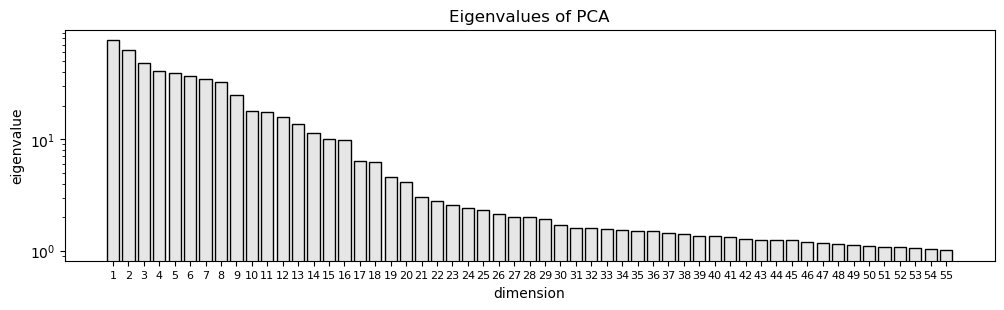

In [20]:
eigenVec = pca.components_
eigenVal = pca.explained_variance_
xplot = np.arange(1, 56)

fig = plt.figure(figsize=(12, 3))
plt.bar(xplot, eigenVal, color = (0.9, 0.9, 0.9), edgecolor = 'black')
plt.xlabel('dimension')
plt.ylabel('eigenvalue')
plt.yscale('log')
plt.xticks(xplot, size=8)
plt.title('Eigenvalues of PCA')
plt.show()

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        94
         2.0       1.00      0.95      0.97      6601
         3.0       0.39      0.93      0.55       224
         4.0       0.87      0.92      0.89        49

    accuracy                           0.95      6968
   macro avg       0.81      0.95      0.85      6968
weighted avg       0.98      0.95      0.96      6968

Accuracy: 0.95


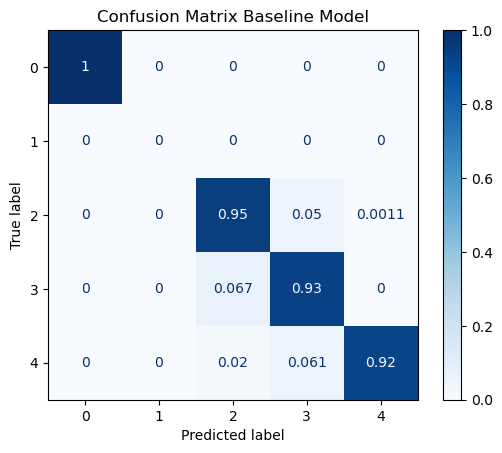

In [36]:
# Model after PCA will be in the modeling notebook
X = pca_df.drop(columns=["grade_ordinal"])
y = pca_df["grade_ordinal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit a baseline logistic regression model, balance the data for each class
baseline_model = LogisticRegression(max_iter=2000, class_weight="balanced")
baseline_model.fit(X_train, y_train)

# predict resistance class
y_pred = baseline_model.predict(X_test)

print(classification_report(y_test, y_pred))

# Display the accuracy
accuracy = np.mean(y_test == y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Baseline Model")
plt.show()

In [37]:
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

Balanced Accuracy: 0.9500875476118337


In [44]:
## Holdout 'Amikacin' and 'Kanamycin' because they are both aminoglycosides
## Holdout 'Levofloxacin' and 'Moxifloxacin' because they are both fluoroquinolones

holdout_drugs = ['Amikacin', 'Kanamycin', 'Levofloxacin', 'Moxifloxacin']
holdout_codes = [code for code, drug in lookup_drugs.items() if drug in holdout_drugs]
print(f"Holdout drug codes: {holdout_codes}")

stress_test = final_ml.copy()

train = stress_test[~stress_test["drug"].isin(holdout_codes)].copy()
test = stress_test[stress_test["drug"].isin(holdout_codes)].copy()

X_train = train.drop(columns=["grade_ordinal"])
y_train = train["grade_ordinal"]
X_test = test.drop(columns=["grade_ordinal"])
y_test = test["grade_ordinal"]

print(f"Training set shape: {X_train.shape}")
print(f"Holdout set shape: {X_test.shape}")

Holdout drug codes: [0, 8, 9, 11]
Training set shape: (27365, 2197)
Holdout set shape: (7473, 2197)


In [30]:
# Now we run PCA to reduce dimensionalty before modeling, since we have so many features from the fingerprints and one-hot encoding. We will keep enough components to explain 95% of the variance.
scaler = StandardScaler()

X_train.replace([np.inf, -np.inf], np.nan, inplace=True) # replace any inf values with nan
X_train = X_train.fillna(0) 
X_test.replace([np.inf, -np.inf], np.nan, inplace=True) # replace any inf values with nan
X_test = X_test.fillna(0) 

XS_train = scaler.fit_transform(X_train)
XS_test = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
pca_features_train = pca.fit_transform(XS_train)
pca_features_test = pca.transform(XS_test)

print(f"Original number of features: {final_ml.shape[1] - 1}")
print(f"Reduced number of features after PCA: {pca_features_train.shape[1]}")

/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_19138/1797647611.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test.replace([np.inf, -np.inf], np.nan, inplace=True) # replace any inf values with nan


Original number of features: 2197
Reduced number of features after PCA: 54


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       134
         2.0       1.00      0.95      0.97      7292
         3.0       0.01      0.28      0.03        18
         4.0       1.00      0.97      0.98        29

    accuracy                           0.95      7473
   macro avg       0.75      0.80      0.75      7473
weighted avg       1.00      0.95      0.97      7473

Accuracy: 0.80


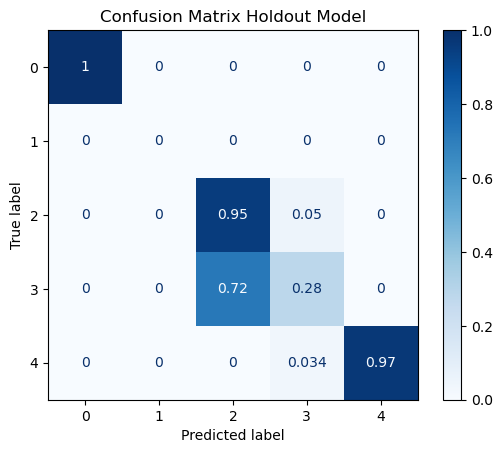

In [49]:
# Fit a new logistic regression model, balance the data for each class
holdout_model = LogisticRegression(max_iter=2000, class_weight="balanced")
holdout_model.fit(pca_features_train, y_train)

# predict resistance class
y_pred = holdout_model.predict(pca_features_test)

print(classification_report(y_test, y_pred))

# Display the accuracy
accuracy = balanced_accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Holdout Model")
plt.show()

In [46]:
print(y_test.value_counts())

grade_ordinal
2.0    7292
0.0     134
4.0      29
3.0      18
Name: count, dtype: int64


              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       134
         2.0       1.00      0.97      0.99      7292
         3.0       0.04      0.44      0.07        18
         4.0       0.97      1.00      0.98        29

    accuracy                           0.97      7473
   macro avg       0.75      0.85      0.76      7473
weighted avg       1.00      0.97      0.98      7473

Accuracy: 0.85


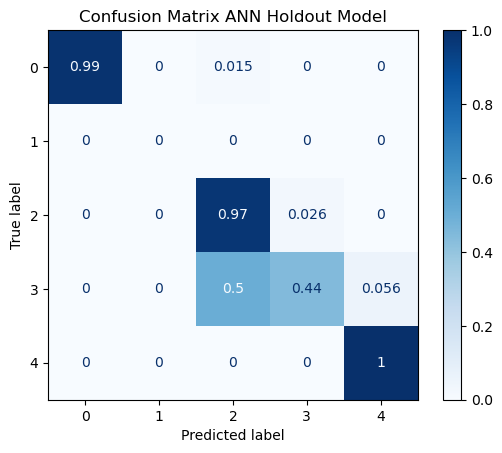

In [48]:
# test using a ANN
mlp_holdout_model = MLPClassifier(max_iter=2000, random_state=42)
mlp_holdout_model.fit(pca_features_train, y_train)
y_pred_mlp = mlp_holdout_model.predict(pca_features_test)
print(classification_report(y_test, y_pred_mlp))

# Display the accuracy
accuracy = balanced_accuracy_score(y_test, y_pred_mlp)
print(f'Accuracy: {accuracy:.2f}')

# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred_mlp, normalize = 'true', labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix ANN Holdout Model")
plt.show()